**CUSTOMER CHURN PREDICTION**

Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Data Loading and Understanding

In [2]:
data = pd.read_csv(r"C:\Users\ramsu\Desktop\AI ML\DataSets\Project\TelcoCustomerChurm.csv")

In [3]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
data.shape

(7043, 21)

In [5]:
data.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Data Cleaning

In [6]:
# Convert binary categorical features into numerical values

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [7]:
data["gender"] = le.fit_transform(data["gender"])
data["Partner"] = le.fit_transform(data["Partner"])
data["Dependents"] = le.fit_transform(data["Dependents"])
data["PhoneService"] = le.fit_transform(data["PhoneService"])
data["PaperlessBilling"] = le.fit_transform(data["PaperlessBilling"])
data["Churn"] = le.fit_transform(data["Churn"])

In [8]:
# Apply one-hot encoding to categorical features

data = pd.get_dummies(data, columns=["MultipleLines", "InternetService", "OnlineSecurity","OnlineBackup", "DeviceProtection", 
                                     "TechSupport","StreamingTV", "StreamingMovies", "Contract","PaymentMethod"],dtype = int,drop_first = True)

In [9]:
data.dtypes

customerID                                   str
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                                 str
Churn                                      int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes                           int64
DeviceProtection_No internet service       int64
DeviceProtection_Yes

In [10]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"],errors = "coerce")

In [11]:
data.drop(columns = "customerID",inplace = True)

In [12]:
data.dtypes

gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes                           int64
DeviceProtection_No internet service       int64
DeviceProtection_Yes                       int64
TechSupport_No inter

In [13]:
data.isnull().sum()

gender                                    0
SeniorCitizen                             0
Partner                                   0
Dependents                                0
tenure                                    0
PhoneService                              0
PaperlessBilling                          0
MonthlyCharges                            0
TotalCharges                             11
Churn                                     0
MultipleLines_No phone service            0
MultipleLines_Yes                         0
InternetService_Fiber optic               0
InternetService_No                        0
OnlineSecurity_No internet service        0
OnlineSecurity_Yes                        0
OnlineBackup_No internet service          0
OnlineBackup_Yes                          0
DeviceProtection_No internet service      0
DeviceProtection_Yes                      0
TechSupport_No internet service           0
TechSupport_Yes                           0
StreamingTV_No internet service 

In [14]:
data= data.dropna()

In [15]:
data.isnull().sum()

gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV

Exploratory Data Analysis

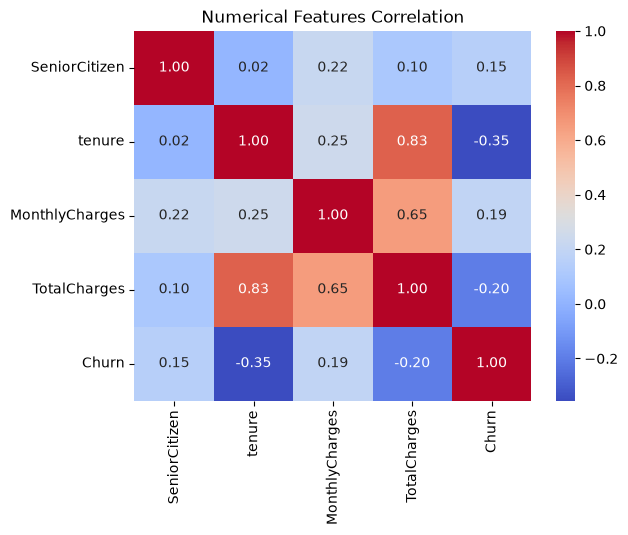

In [16]:
# Check multicollinearity among numerical features

corr = data[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]].corr()
sns.heatmap(corr, annot = True, fmt=".2f", cmap = "coolwarm")
plt.title("Numerical Features Correlation")
plt.show()

Data Preprocessing

In [17]:
# Separate features and target

x = data.drop(columns="Churn")
y = data["Churn"]

In [18]:
# Split data into training and testing sets

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.25, random_state = 15, stratify=y)

In [19]:
# Standardize numerical features

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [20]:
# Import Logistic Regression

from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(x_train,y_train)
log_model_pred = log_model.predict(x_test)

# Evaluate model performance

from sklearn.metrics import classification_report
print("Training Accuracy: ",log_model.score(x_train,y_train))
print("Testing Accuracy: ",log_model.score(x_test,y_test))
print()
print( classification_report(y_test,log_model_pred))

Training Accuracy:  0.8094425483503982
Testing Accuracy:  0.8060295790671217

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1291
           1       0.66      0.55      0.60       467

    accuracy                           0.81      1758
   macro avg       0.75      0.72      0.74      1758
weighted avg       0.80      0.81      0.80      1758



In [21]:
# Import Decision Tree

from sklearn.tree import DecisionTreeClassifier
dec_tree_model = DecisionTreeClassifier(max_depth=5,random_state=15)
dec_tree_model.fit(x_train,y_train)
dec_tree_model_pred = dec_tree_model.predict(x_test)

# Evaluate model performance

from sklearn.metrics import classification_report
print("Training Accuracy: ",dec_tree_model.score(x_train,y_train))
print("Testing Accuracy: ",dec_tree_model.score(x_test,y_test))
print()
print( classification_report(y_test,dec_tree_model_pred))

Training Accuracy:  0.807356844899507
Testing Accuracy:  0.7935153583617748

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1291
           1       0.63      0.53      0.58       467

    accuracy                           0.79      1758
   macro avg       0.74      0.71      0.72      1758
weighted avg       0.78      0.79      0.79      1758



In [22]:
# Import Random Forest

from sklearn.ensemble import RandomForestClassifier
rand_frt_model = RandomForestClassifier(n_estimators = 100, max_depth = 5, min_samples_leaf = 5, random_state = 15)
rand_frt_model.fit(x_train,y_train)
rand_frt_model_pred = rand_frt_model.predict(x_test)

# Evaluate model performance

from sklearn.metrics import classification_report
print("Training Accuracy: ",rand_frt_model.score(x_train,y_train))
print("Testing Accuracy: ",rand_frt_model.score(x_test,y_test))
print()
print( classification_report(y_test,rand_frt_model_pred))

Training Accuracy:  0.80128934395146
Testing Accuracy:  0.7957906712172924

              precision    recall  f1-score   support

           0       0.81      0.94      0.87      1291
           1       0.70      0.40      0.51       467

    accuracy                           0.80      1758
   macro avg       0.76      0.67      0.69      1758
weighted avg       0.78      0.80      0.78      1758



In [23]:
# Import XGBoost

from xgboost import XGBClassifier
xgb_model = XGBClassifier(n_estimators = 100, max_depth = 5, subsample= 0.75,learning_rate = 0.1,eval_metric="logloss")
xgb_model.fit(x_train,y_train)
xgb_model_pred = xgb_model.predict(x_test)

# Evaluate model performance

from sklearn.metrics import classification_report
print("Training Accuracy: ",xgb_model.score(x_train,y_train))
print("Testing Accuracy: ",xgb_model.score(x_test,y_test))
print()
print( classification_report(y_test,xgb_model_pred))

Training Accuracy:  0.8530527114144861
Testing Accuracy:  0.8065984072810012

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1291
           1       0.67      0.53      0.59       467

    accuracy                           0.81      1758
   macro avg       0.76      0.72      0.73      1758
weighted avg       0.80      0.81      0.80      1758



Hyperparameter Tuning

In [24]:
# Import GridSearchCV for LogisticRegression

from sklearn.model_selection import GridSearchCV
log_grid = GridSearchCV(LogisticRegression(max_iter = 1000), {
    "C" : [0.1, 1, 10] }, cv = 3, scoring = "precision", n_jobs = -1)
log_grid.fit(x_train,y_train)

print("Best Parameters", log_grid.best_estimator_)

Best Parameters LogisticRegression(C=0.1, max_iter=1000)


In [25]:
# Import GridSearchCV for DecisionTree

dec_tree_grid = GridSearchCV(DecisionTreeClassifier(random_state = 15), {
    "max_depth" : [1,3,5,8,None], "min_samples_leaf" : [1,2,3,4,7]}, cv = 4, scoring = "precision", n_jobs = -1)
dec_tree_grid.fit(x_train,y_train)

print("Best parameter for : " , dec_tree_grid.best_estimator_)

Best parameter for :  DecisionTreeClassifier(max_depth=3, random_state=15)


In [26]:
# Import GridSearchCV for RandomForest

rand_frt_grid = GridSearchCV(RandomForestClassifier(random_state = 15), {
    "max_depth" : [3,4,None], "n_estimators" : [100,200], "min_samples_leaf" : [1,3,4]},
    cv = 4, scoring = "precision", n_jobs = -1)
rand_frt_grid.fit(x_train,y_train)

print("Best Parameter for :", rand_frt_grid.best_estimator_)

Best Parameter for : RandomForestClassifier(max_depth=3, n_estimators=200, random_state=15)


In [27]:
# Import GridSearchCV for XGBoost

xbg_grid = GridSearchCV(XGBClassifier(random_state= 15,eval_metric="logloss"), {
    "max_depth" : [2,3,5] , "n_estimators" : [100,300], "subsample" : [0.9,0.8],  } ,
                        cv = 3, scoring = "precision", n_jobs = -1)
xbg_grid.fit(x_train,y_train)

print("Best Parameter for : ", xbg_grid.best_estimator_)

Best Parameter for :  XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)


Tuned Model Evaluation

In [28]:
best_log_model = log_grid.best_estimator_
best_log_model_pred = best_log_model.predict(x_test)

print("Training Accuracy: ",best_log_model.score(x_train,y_train))
print("Testing Accuracy: ",best_log_model.score(x_test,y_test))
print()
print( classification_report(y_test,best_log_model_pred))

Training Accuracy:  0.8084945013272659
Testing Accuracy:  0.8043230944254836

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1291
           1       0.66      0.54      0.60       467

    accuracy                           0.80      1758
   macro avg       0.75      0.72      0.73      1758
weighted avg       0.80      0.80      0.80      1758



In [29]:
dec_tree_model = dec_tree_grid.best_estimator_
best_dt_model_pred = dec_tree_model.predict(x_test)

print("Training Accuracy: ", dec_tree_model.score(x_train, y_train))
print("Testing Accuracy: ", dec_tree_model.score(x_test, y_test))
print()
print(classification_report(y_test, best_dt_model_pred))

Training Accuracy:  0.7904816078877512
Testing Accuracy:  0.78839590443686

              precision    recall  f1-score   support

           0       0.80      0.94      0.87      1291
           1       0.70      0.36      0.47       467

    accuracy                           0.79      1758
   macro avg       0.75      0.65      0.67      1758
weighted avg       0.77      0.79      0.76      1758



In [30]:
best_rand_frt_model = rand_frt_grid.best_estimator_
best_rand_frt_model_pred = best_rand_frt_model.predict(x_test)

print("Training Accuracy: ", best_rand_frt_model.score(x_train, y_train))
print("Testing Accuracy: ", best_rand_frt_model.score(x_test, y_test))
print()
print(classification_report(y_test, best_rand_frt_model_pred))

Training Accuracy:  0.7863102009859689
Testing Accuracy:  0.7792946530147895

              precision    recall  f1-score   support

           0       0.78      0.96      0.87      1291
           1       0.73      0.27      0.39       467

    accuracy                           0.78      1758
   macro avg       0.76      0.62      0.63      1758
weighted avg       0.77      0.78      0.74      1758



In [31]:
best_xgb_model = xbg_grid.best_estimator_
best_xgb_model_pred = best_xgb_model.predict(x_test)

print("Training Accuracy: ", best_xgb_model.score(x_train, y_train))
print("Testing Accuracy: ", best_xgb_model.score(x_test, y_test))
print()
print(classification_report(y_test, best_xgb_model_pred))

Training Accuracy:  0.8193022373909746
Testing Accuracy:  0.8014789533560864

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1291
           1       0.66      0.51      0.58       467

    accuracy                           0.80      1758
   macro avg       0.75      0.71      0.72      1758
weighted avg       0.79      0.80      0.79      1758



In [32]:
# Import confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

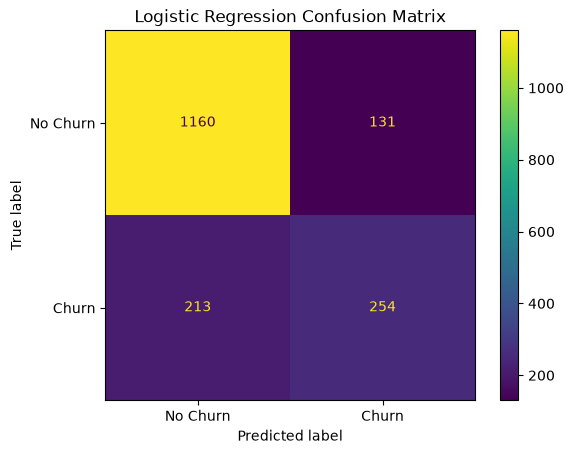

In [33]:
# Logistic Regression confusion matrix
log_cm = confusion_matrix(y_test, best_log_model_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=log_cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

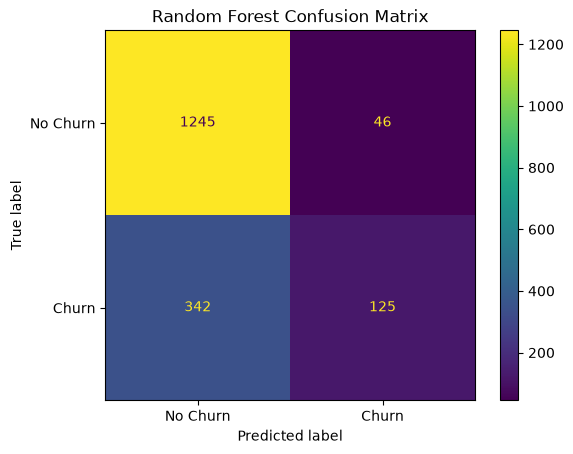

In [34]:
# Random Forest confusion matrix
rf_cm = confusion_matrix(y_test, best_rand_frt_model_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [35]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Store tuned models and predictions
models = {
    "Logistic Regression": (best_log_model, best_log_model_pred),
    "Decision Tree": (dec_tree_model, best_dt_model_pred),
    "Random Forest": (best_rand_frt_model, best_rand_frt_model_pred),
    "XGBoost": (best_xgb_model, best_xgb_model_pred)
}

# Compare model performance
results = []

for name, (model, predictions) in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

comparison_df = pd.DataFrame(results)

# Display comparison table
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.804323,0.659740,0.543897,0.596244
1,Decision Tree,0.788396,0.698745,0.357602,0.473088
2,Random Forest,0.779295,0.730994,0.267666,0.391850
3,XGBoost,0.801479,0.663889,0.511777,0.577993


**Business Objective**

Identify customers who are likely to churn and support targeted customer retention strategies.

The project aims to evaluate machine learning models for predicting customer churn and understanding the trade-offs between precision and recall.

**Conclusion**

This project developed a customer churn prediction system using machine learning.

The workflow included data cleaning, exploratory data analysis, feature encoding, model training, and hyperparameter tuning using GridSearchCV.

Four machine learning models were evaluated using accuracy, precision, recall, and F1-score.

**Final Model : Logistic Regression**

Logistic Regression was selected as the primary model because it provides a better balance of accuracy and recall compared with the other evaluated models.

The model can support data-driven customer retention strategies by identifying customers who are likely to churn.

In [36]:
import joblib

joblib.dump(best_log_model, "final_logistic_model.pkl")
joblib.dump(scaler,"scaler.pkl")

print("Final model saved successfully!")

Final model saved successfully!
